In [4]:
function gausslegendre(n; tol=eps(), maxiter=100)
    x = zeros(n) #initialise x
    w = zeros(n) #initialise w
    for i in 1:n
        xi = cos(pi * (i - 0.25) / (n + 0.5)) #Initial guess for Legendre Polynomials

        #Newton Iteration
        for _ in 1:maxiter 
            p0 = 1.0 
            p1 = xi
            for k in 2:n
                p2 = ((2k - 1) * xi * p1 - (k - 1) * p0) / k  #Legendre polynomial recurrence relation
                p0, p1 = p1, p2
            end
            dp = n * (xi * p1 - p0) / (xi^2 - 1)  #Derivative of Legendre polynomial using the recurrence relation
            xi_new = xi - p1 / dp

            if abs(xi - xi_new) < tol #Iteration breaks when within the tolerance
                xi = xi_new
                break
            end
            xi = xi_new
        end
        
        #Recalculate Legendre Polynomial at each node
        p0 = 1.0
        p1 = xi
        for k in 2:n
            p2 = ((2k - 1) * xi * p1 - (k - 1) * p0) / k
            p0, p1 = p1, p2
        end
        dp = n * (xi * p1 - p0) / (xi^2 - 1)

        #Compute nodes and their respective weights
        x[i] = xi
        w[i] = 2 / ((1 - xi^2) * dp^2)
    end
    return x, w  #Final Nodes and Weights of Legendre Polynomials
end

gausslegendre (generic function with 1 method)

In [6]:
const GL_RULES = Vector{Tuple{Vector{Float64}, Vector{Float64}}}(undef, 50) #preallocated vector to store the wieghts and nodes

for n in 1:50
    GL_RULES[n] = gausslegendre(n) #precalculating wieghts and nodes from 1 to 50
end

In [8]:
function legendre_integrate_precomputed(f, a, b, n)
    x, w = GL_RULES[n] #retrieving predetermined wieghts and nodes

    c1 = (b - a)/2 #change of bounds constants
    c2 = (a + b)/2

    s = 0.0
    for i in eachindex(x)
        s += w[i] * f(c1*x[i] + c2) #Sum wieghts and nodes
    end

    return c1 * s #Final approximation
end

legendre_integrate_precomputed (generic function with 1 method)

In [10]:
function legendre_integrate(f, a, b, n)
    x, w = gausslegendre(n) #Calculates weights and nodes for Legendre polynomials
    t = zeros(n) #Initialises t
    for i=1:n
        t[i] = (b - a)/2 .* x[i] .+ (a + b)/2 #Adjust nodes to correct bounds
    end
    sum = 0 #Initialise sum
    for i=1:n
        sum += w[i]*f(t[i]) #Sums the weighted function at the adjusted nodes
    end
    return (b - a)/2 * sum #Final approximation
end

legendre_integrate (generic function with 1 method)

In [12]:
function simpsonsrule(f,a,b,n)
    deltax = (b-a)/(n) #Width of subintervals
    sum = f(a) + f(b) #Sum end points
    for i = 1:n-1
        xi = a + deltax*i #Current evalutaion point
        if i%2==1
            sum += 4*f(xi) #Sum odd terms
        else
            sum += 2*f(xi) #Sum even terms
        end
    end
    return (deltax/3)*sum  #Final approximation
end

simpsonsrule (generic function with 1 method)

In [14]:
function find_n(method, f, a, b, exact, tol; nmax=10_000) #Find number of nodes to reach a tolerance
    n = 2

    #Iterating over n
    while n <= nmax
        approx = method(f, a, b, n)

        if abs(approx - exact) < tol #Tests if approximation is within tolerance
            return n 
        end

        n += 2
    end

    error("Tolerance not reached")
end

find_n (generic function with 1 method)

In [16]:
f(x) = sin(x) #Test function

#Integration bounds
a = 0.0
b = 1.0

exact = 1 - cos(1) #Exact integration result

tol = 1e-10

#Number of nodes required for each method at a set tolerance
n_legendre = find_n(legendre_integrate, f, a, b, exact, tol) 
n_simpson = find_n(simpsonsrule, f, a, b, exact, tol)

println(n_legendre)
println(n_simpson)

6
72


In [18]:
using BenchmarkTools 
f(x) = sin(x) #Test function

#Bounds
a = 0.0 
b = 1.0 
n = 50 #Nodes

@benchmark legendre_integrate($f, $a, $b, $n) evals=1 #Benchmark evaluation for Legendre 

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  34.708 μs … 113.291 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     34.875 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   35.212 μs ±   2.227 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ██▄▁ ▁▂             ▁▁                                       ▂
  █████████▇▇▆▆▅▅▄▅▁▅▇██▇▃▅▅▆▅▅▅▆▆▅▅▅▄▆▄▃▅▅▆▅▆▅▅▅▃▅▅▄▅▄▅▃▄▃▅▅▅ █
  34.7 μs       Histogram: log(frequency) by time      43.4 μs <

 Memory estimate: 1.41 KiB, allocs estimate: 6.

In [19]:
using BenchmarkTools

f(x) = sin(x) #Test function

#Bounds
a = 0.0
b = 1.0
n = 50 #Nodes

@benchmark simpsonsrule($f, $a, $b, $n) evals=1 #Benchmark evaluation for Simpsons

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):   42.000 ns … 916.000 ns  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):      84.000 ns               ┊ GC (median):    0.00%
 Time  (mean ± σ):   101.433 ns ±  22.520 ns  ┊ GC (mean ± σ):  0.00% ± 0.00%

                                █                             ▄  
  ▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▂
  42 ns            Histogram: frequency by time          125 ns <

 Memory estimate: 0 bytes, allocs estimate: 0.

In [20]:
using BenchmarkTools

f(x) = sin(x) #Test function

#Bounds
a = 0.0
b = 1.0
n = 72 #Nodes

@benchmark simpsonsrule($f, $a, $b, $n) evals=1 #Benchmark evaluation for Simpsons

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):   83.000 ns …  3.084 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     125.000 ns              ┊ GC (median):    0.00%
 Time  (mean ± σ):   137.431 ns ± 36.323 ns  ┊ GC (mean ± σ):  0.00% ± 0.00%

                               █                                
  ▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▇ ▂
  83 ns           Histogram: frequency by time          167 ns <

 Memory estimate: 0 bytes, allocs estimate: 0.

In [21]:
using BenchmarkTools 
f(x) = sin(x) #Test function

#Bounds
a = 0.0 
b = 1.0 

@benchmark legendre_integrate_precomputed($f, $a, $b,6) evals=1 #Benchmark evaluation for 6 node Legendre

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):   0.001 ns … 834.000 ns  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     41.000 ns               ┊ GC (median):    0.00%
 Time  (mean ± σ):   21.796 ns ±  22.404 ns  ┊ GC (mean ± σ):  0.00% ± 0.00%

  █                                                          ▄  
  █▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▇█ ▂
  0.001 ns        Histogram: frequency by time           42 ns <

 Memory estimate: 0 bytes, allocs estimate: 0.

In [22]:
using BenchmarkTools 
f(x) = sin(x) #Test function

#Bounds
a = 0.0 
b = 1.0 

@benchmark legendre_integrate_precomputed($f, $a, $b,50) evals=1 #Benchmark evaluation for 50 node Legendre

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):   41.000 ns …  1.042 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     125.000 ns              ┊ GC (median):    0.00%
 Time  (mean ± σ):   112.904 ns ± 21.528 ns  ┊ GC (mean ± σ):  0.00% ± 0.00%

                                                             █  
  ▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▆▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▂
  41 ns           Histogram: frequency by time          125 ns <

 Memory estimate: 0 bytes, allocs estimate: 0.

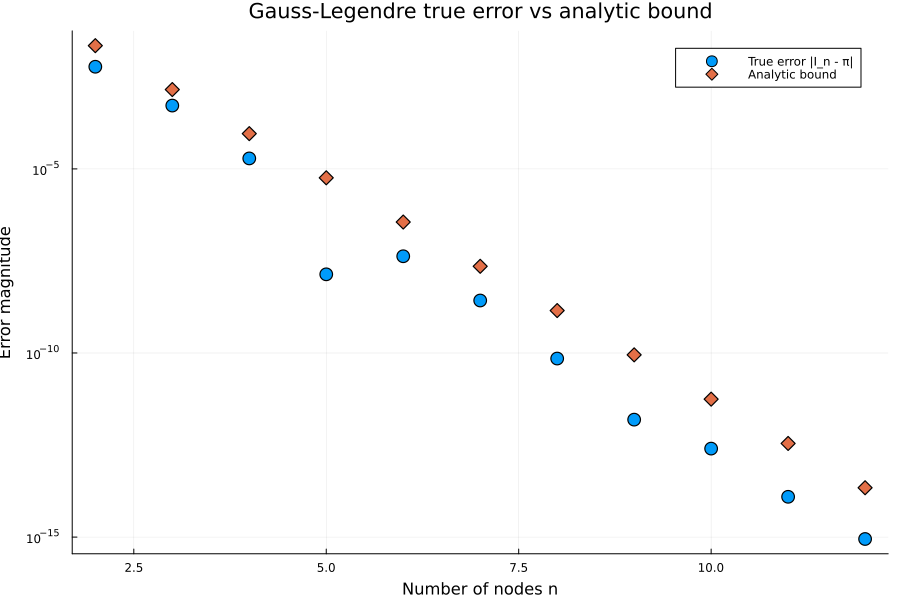

In [23]:
using Plots

exact_val = π #Integration true value
nvals = 2:12 #Test nodes range
f(x) = 4 / (1 + x^2) #Integration function

function theoretical_bound(n) #Calculates theoretical bound for Legendre polynomials
    return Float64(4 * (factorial(big(n))^4) / ((2n + 1) * factorial(big(2n))^2))
end

#Initialises bounds and errors
approx_vals = Float64[]
bound_vals = Float64[]
true_error_vals = Float64[]

#Evaluates the numerical integral, analytical bound and true error of the test function
for n in nvals
    approx_val = legendre_integrate(f, 0.0, 1.0, n)
    bound_val = theoretical_bound(n)
    true_error_val = abs(approx_val - exact_val)
    push!(approx_vals, approx_val)
    push!(bound_vals, bound_val)
    push!(true_error_vals, true_error_val)
end

#Defines the true error plot
p = plot(
    nvals,
    true_error_vals,
    seriestype = :scatter,
    yscale = :log10,
    marker = :circle,
    markersize = 7,
    xlabel = "Number of nodes n",
    ylabel = "Error magnitude",
    title = "Gauss-Legendre true error vs analytic bound",
    label = "True error |I_n - π|",
    size = (900, 600),
    legend = :topright
)

#Defines the anlaytical bounds plot
plot!(
    p,
    nvals,
    bound_vals,
    seriestype = :scatter,
    marker = :diamond,
    markersize = 7,
    label = "Analytic bound"
)

display(p)

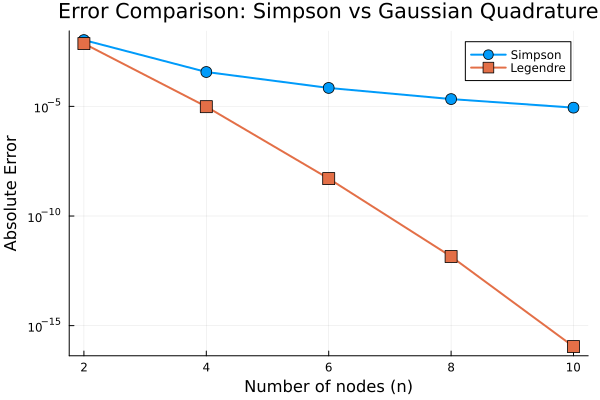

In [24]:
using Plots

f(x) = (1 / sqrt(2*pi)) * exp(-x^2 / 2) #Test function
exact = 0.6826894921370859 #Integration true value
ns = [2, 4, 6, 8, 10] #Test nodes range

#Initialises errors
errors_simpson = Float64[]
errors_legendre = Float64[]

#Evaluates errors for nodes range for different integration methods
for n in ns
    push!(errors_simpson, abs(simpsonsrule(f, -1, 1, n) - exact))
    push!(errors_legendre, abs(legendre_integrate(f, -1, 1, n) - exact))
end

#Defines the true error for Simpsons method plot
p = plot(ns,
    errors_simpson,
    label = "Simpson",
    marker = :circle,
    xlabel = "Number of nodes (n)",
    ylabel = "Absolute Error",
    title = "Error Comparison: Simpson vs Gaussian Quadrature",
    yscale = :log10,
    linewidth = 2,
    markersize = 6
)

#Defines the true error for Legendre method plot
plot!(
    p,
    ns,
    errors_legendre,
    label = "Legendre",
    marker = :square,
    linewidth = 2,
    markersize = 6
)

display(p)

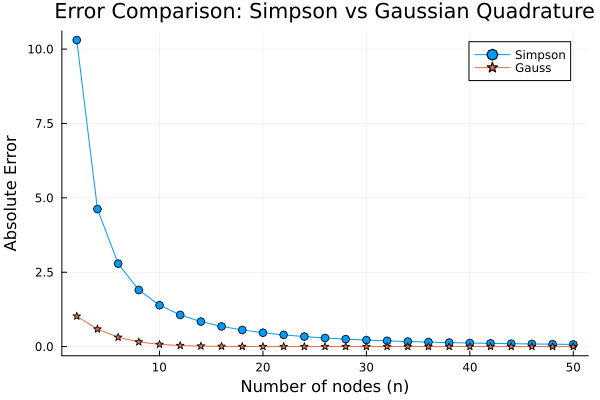

In [25]:
using Plots

f(x) = 1/(x*sqrt(x+1)) #Test function
exact = 1.563079016240671 #Integration true value
ns = [2, 4, 6, 8, 10, 12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,50] #Test nodes range

#Initialises errors
errors_simpson = []
errors_gauss = []

#Evaluates errors for nodes range for different integration methods
for n in ns
    push!(errors_simpson, abs(simpsonsrule(f,1,100,n) - exact))
    push!(errors_gauss, abs(legendre_integrate(f,1,100,n) - exact))
end

#Defines the true error for Simpsons method plot
p = plot(ns, errors_simpson,
    label = "Simpson",
    marker = :o,
    xlabel = "Number of nodes (n)",
    ylabel = "Absolute Error",
    title = "Error Comparison: Simpson vs Gaussian Quadrature"
)

#Defines the true error for Legendre method plot
plot!(p, ns, errors_gauss, label="Gauss", marker=:s)

display(p)

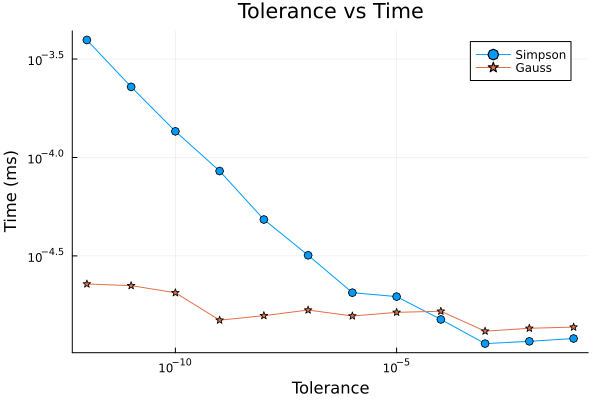

"/Users/rileymicono/Documents/School/UWA/Year 3/Sem 1/MATH2064/group project/tolerence vs time.pdf"

In [58]:
using Plots
using BenchmarkTools

f(x) = sin(x)
exact = 1 - cos(1)

#Tolerance list
tols = [1e-1,1e-2, 1e-3,1e-4, 1e-5,1e-6, 1e-7,1e-8, 1e-9,1e-10, 1e-11,1e-12]

#Initialise timing arrays
times_simpson = []
times_gauss = []

#Find n and benchmark each tolerance
for tol in tols

    n_simpson = find_n(simpsonsrule, f, 0, 1, exact, tol)
    n_gauss    = find_n(legendre_integrate, f, 0, 1, exact, tol)

    bench_simpson = @benchmark simpsonsrule($f, 0, 1, $n_simpson) evals=1
    bench_gauss   = @benchmark legendre_integrate_precomputed($f, 0, 1, $n_gauss) evals=1

    push!(times_simpson, mean(bench_simpson).time)
    push!(times_gauss, mean(bench_gauss).time)
end


times_simpson_ms = times_simpson ./ 1e6
times_gauss_ms = times_gauss ./ 1e6

#Define plot for Tolerence vs time of simpsons method
p = plot(
    tols,
    times_simpson_ms,
    xscale = :log10,
    yscale = :log10,
    label = "Simpson",
    marker = :o,
    xlabel = "Tolerance",
    ylabel = "Time (ms)",
    title = "Tolerance vs Time"
)
#define plot for tolerence vs time of gauss's method
plot!(
    p,
    tols,
    times_gauss_ms,
    label = "Gauss",
    marker = :s
)

display(p)